In [4]:
# ==========================================
# 1. Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics.pairwise import cosine_similarity
import pickle


In [5]:
# ==========================================
# 2. Load Cleaned Dataset
# ==========================================

df = pd.read_csv("../data/cleaned_data.csv")

df.head()


,id,name,city,rating,rating_count,cost,cuisine,link,address,menu
0,567335,AB FOODS POINT,Abohar,4.0,0.0,200.0,"Beverages,Pizzas",https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50.0,200.0,"Sweets,Bakery",https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100.0,100.0,Beverages,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20.0,250.0,"Fast Food,Indian",https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,4.0,0.0,250.0,"Italian-American,Fast Food",https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


In [6]:
# ==========================================
# 3. Selecting Features for Recommendation
# ==========================================

features = df[['city', 'cuisine', 'rating', 'rating_count', 'cost']]

features.head()


,city,cuisine,rating,rating_count,cost
0,Abohar,"Beverages,Pizzas",4.0,0.0,200.0
1,Abohar,"Sweets,Bakery",4.4,50.0,200.0
2,Abohar,Beverages,3.8,100.0,100.0
3,Abohar,"Fast Food,Indian",3.7,20.0,250.0
4,Abohar,"Italian-American,Fast Food",4.0,0.0,250.0


In [7]:
# ==========================================
# 4. Apply One Hot Encoding (SPARSE VERSION)
# ==========================================

encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')

encoded_categorical = encoder.fit_transform(features[['city', 'cuisine']])



In [8]:
from scipy.sparse import hstack

# ==========================================
# 5. Combine Numerical + Encoded (Sparse)
# ==========================================

numerical_data = features[['rating', 'rating_count', 'cost']].values

# Convert to CSR format 
final_encoded_sparse = hstack([numerical_data, encoded_categorical]).tocsr()


In [9]:
# ==========================================
# 6. Save Encoder
# ==========================================

with open("../models/encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print("Encoder saved successfully!")


Encoder saved successfully!


In [25]:
# ==========================================
# 7. COSINE SIMILARITY IMPLEMENTATION
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity

def recommend_cosine(index, data, top_n=5):
    
    selected_vector = data[index:index+1]
    
    similarity_scores = cosine_similarity(selected_vector, data).flatten()
    
    similar_indices = similarity_scores.argsort()[::-1][1:top_n+1]
    
    return similar_indices



In [26]:
test_index = 10

cosine_indices = recommend_cosine(test_index, final_encoded_sparse)



In [14]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

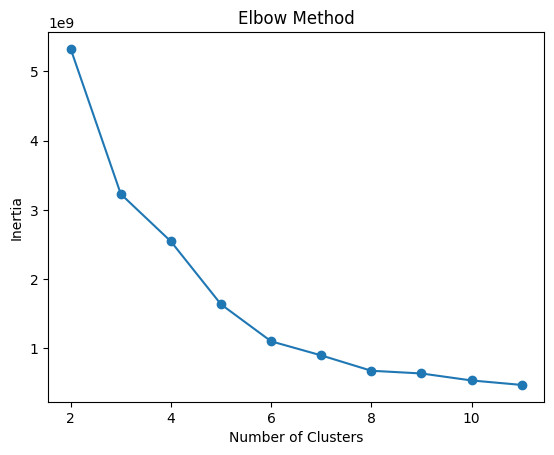

In [ ]:
#==========================================
# 8. K-MEANS CLUSTERING IMPLEMENTATION (Elbow Method (To Choose Optimal K))
#==========================================
inertia = []

for k in range(2, 12):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(final_encoded_sparse)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 12), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [17]:
# Train Final K-Means Model
kmeans = KMeans(n_clusters=10, random_state=42)
clusters = kmeans.fit_predict(final_encoded_sparse)

df['cluster'] = clusters

In [18]:
# K-Means Recommendation Function
def recommend_kmeans(index, top_n=5):
    
    cluster_id = df.iloc[index]['cluster']
    
    same_cluster = df[df['cluster'] == cluster_id]
    
    same_cluster = same_cluster.drop(index)
    
    return same_cluster.sort_values(by='rating', ascending=False).head(top_n)

In [19]:
#Test K-Means Recommendation
recommend_kmeans(10)[['name', 'city', 'cuisine', 'rating', 'cost']]

,name,city,cuisine,rating,cost
43522,Bronies,"Adyar,Chennai","American,Desserts",5.0,400.0
109312,House of Momo,"Scruz Bandra East,Mumbai","Chinese,Asian",5.0,350.0
52711,Gelato Vinto,"Greater Kailash New,Delhi",Ice Cream,5.0,400.0
140728,Chenab Kitchen,"Piplod,Surat","Punjabi,North Indian",5.0,400.0
51858,Regalo Delights,"Ashok Vihar,Delhi",Bakery,5.0,300.0


In [27]:
#==========================================
#9. MODEL COMPARISON
#==========================================

#Compare Recommendations Side by Side
print("Cosine Similarity Recommendations:")
display(df.iloc[cosine_indices][['name','city','cuisine','rating','cost']])

print("\nK-Means Recommendations:")
display(recommend_kmeans(10)[['name','city','cuisine','rating','cost']])

Cosine Similarity Recommendations:


,name,city,cuisine,rating,cost
13731,Prezzed Juicery,"Indiranagar,Bangalore","Juices,Beverages",4.0,300.0
80044,Shakes & Juices Lassi Point,"Kukatpally,Hyderabad","Juices,Beverages",4.0,300.0
38087,JUICE DUDEZ,"Royapettah,Chennai","Juices,Beverages",4.0,300.0
72161,Made To Order,"Jubilee Hills,Hyderabad","Juices,Beverages",4.0,300.0
76341,Juice Time,"Miyapur,Hyderabad","Juices,Beverages",4.0,300.0



K-Means Recommendations:


,name,city,cuisine,rating,cost
43522,Bronies,"Adyar,Chennai","American,Desserts",5.0,400.0
109312,House of Momo,"Scruz Bandra East,Mumbai","Chinese,Asian",5.0,350.0
52711,Gelato Vinto,"Greater Kailash New,Delhi",Ice Cream,5.0,400.0
140728,Chenab Kitchen,"Piplod,Surat","Punjabi,North Indian",5.0,400.0
51858,Regalo Delights,"Ashok Vihar,Delhi",Bakery,5.0,300.0


In [29]:
# Similarity Score Comparison
def evaluate_cosine(index):
    selected_vector = final_encoded_sparse[index:index+1]
    scores = cosine_similarity(selected_vector, final_encoded_sparse).flatten()
    return scores.mean()

def evaluate_kmeans(index):
    
    cluster_id = df.iloc[index]['cluster']
    
    cluster_indices = df[df['cluster'] == cluster_id].index
    
    selected_vector = final_encoded_sparse[index:index+1]
    
    cluster_vectors = final_encoded_sparse[cluster_indices]
    
    similarity_scores = cosine_similarity(selected_vector, cluster_vectors).flatten()
    
    return similarity_scores.mean()

import random

indices = random.sample(range(len(df)), 5)

cos_scores = []
kmeans_scores = []

for i in indices:
    cos_scores.append(evaluate_cosine(i))
    kmeans_scores.append(evaluate_kmeans(i))

print("Average Cosine Similarity Score:", np.mean(cos_scores))
print("Average K-Means Similarity Score:", np.mean(kmeans_scores))

Average Cosine Similarity Score: 0.9721271637276112
Average K-Means Similarity Score: 0.98680380015494


In [30]:
# Rating Difference Comparison
def rating_difference(index, method="cosine"):
    
    original_rating = df.iloc[index]['rating']
    
    if method == "cosine":
        indices = recommend_cosine(index, final_encoded_sparse)
        recommended = df.iloc[indices]
    else:
        recommended = recommend_kmeans(index)
    
    return abs(recommended['rating'].mean() - original_rating)


In [31]:
print("Cosine Rating Difference:", rating_difference(10, "cosine"))
print("KMeans Rating Difference:", rating_difference(10, "kmeans"))

Cosine Rating Difference: 0.0
KMeans Rating Difference: 1.0


In [32]:
# Cost Difference Comparison
def cost_difference(index, method="cosine"):
    
    original_cost = df.iloc[index]['cost']
    
    if method == "cosine":
        indices = recommend_cosine(index, final_encoded_sparse)
        recommended = df.iloc[indices]
    else:
        recommended = recommend_kmeans(index)
    
    return abs(recommended['cost'].mean() - original_cost)

In [33]:
print("Cosine Cost Difference:", cost_difference(10, "cosine"))
print("KMeans Cost Difference:", cost_difference(10, "kmeans"))

Cosine Cost Difference: 0.0
KMeans Cost Difference: 70.0


In [34]:
# Execution Time Comparison
import time

start = time.time()
recommend_cosine(10, final_encoded_sparse)
cosine_time = time.time() - start

start = time.time()
recommend_kmeans(10)
kmeans_time = time.time() - start

print("Cosine Time:", cosine_time)
print("KMeans Time:", kmeans_time)

Cosine Time: 0.04471778869628906
KMeans Time: 0.07512426376342773


In [ ]:
# FINAL COMPARISON 
import random
import numpy as np
import time

# Pick 5 random restaurants
indices = random.sample(range(len(df)), 5)

cos_sim = []
kmeans_sim = []

cos_rating = []
kmeans_rating = []

cos_cost = []
kmeans_cost = []

for i in indices:
    
    cos_sim.append(evaluate_cosine(i))
    kmeans_sim.append(evaluate_kmeans(i))
    
    cos_rating.append(rating_difference(i, "cosine"))
    kmeans_rating.append(rating_difference(i, "kmeans"))
    
    cos_cost.append(cost_difference(i, "cosine"))
    kmeans_cost.append(cost_difference(i, "kmeans"))

# Execution Time
start = time.time()
recommend_cosine(10, final_encoded_sparse)
cos_time = time.time() - start

start = time.time()
recommend_kmeans(10)
kmeans_time = time.time() - start

# Create comparison table
comparison_table = pd.DataFrame({
    "Metric": [
        "Average Similarity Score",
        "Average Rating Difference (Lower Better)",
        "Average Cost Difference (Lower Better)",
        "Execution Time (seconds)"
    ],
    "Cosine Similarity": [
        np.mean(cos_sim),
        np.mean(cos_rating),
        np.mean(cos_cost),
        cos_time
    ],
    "K-Means": [
        np.mean(kmeans_sim),
        np.mean(kmeans_rating),
        np.mean(kmeans_cost),
        kmeans_time
    ]
})

comparison_table

,Metric,Cosine Similarity,K-Means
0,Average Similarity Score,0.966971,0.984720
1,Average Rating Difference (Lower Better),0.004000,0.980000
2,Average Cost Difference (Lower Better),11.600000,42.000000
3,Execution Time (seconds),0.041896,0.073538
